In [1]:
#Packages to use pytorch
import copy
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
#

# Tensores en pytorch
Son estructuras similares a los arreglos de numpy y se utilizan para entrenar modelos de redes profundas.


In [2]:
empty_data = torch.empty(3, 4) # Datos con valores arbitrarios
print(type(empty_data))
print("empty data : \n",empty_data)

costume_data = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
print("costume_data : \n",costume_data)


<class 'torch.Tensor'>
empty data : 
 tensor([[ 1.3747e-13,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [-6.0100e-33,  4.0349e-41, -6.0850e-33,  4.0349e-41],
        [-5.8640e-33,  4.0349e-41, -5.9109e-33,  4.0349e-41]])
costume_data : 
 tensor([[1., 2., 3.],
        [4., 5., 6.]])


## Operaciones
Se pueden definir distintos tipos de operacions

In [3]:

x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

z = x + y
print(z)

z = x - y
print(z)

z = x * y
print(z)

z = x / y
print(z)


tensor([5, 7, 9])
tensor([-3, -3, -3])
tensor([ 4, 10, 18])
tensor([0.2500, 0.4000, 0.5000])


## Tensores y gradientes
El principal rol de los tensores es ser unidades de almacenaje y manejo de gradientes para todo tipo de operaciones. A partir de definir operaciones matemáticas en pytorch uno es capaz de optimizar el un problema a partir de minimizar la función de pérdida. En el ecosistema de pytorch los tensores van a realizar y asociar las operaciones matemáticas con los gradientes correspondientes sin que tengamos que preocuparnos de implementar las derivadas nosotros mismos.


In [4]:


# 1.
# Partimos de un valor aleatorio
x = torch.tensor([0.0], requires_grad=True)

a = 1.8
b = -2.7
c = 3.6

# 2. Define the optimizer
optimizer = optim.SGD([x], lr=0.01) ## JUGAR CON EL LR.

# 3. Optimization Loop
for i in range(100):
    # Zero gradients from previous iteration
    optimizer.zero_grad()

    # Compute loss: L(x)
    loss = (a * x**2  + b* x + c) # FORWARD Operation

    # Backpropagation: compute gradients
    loss.backward()

    # Update x based on gradients
    optimizer.step()

    if i % 20 == 0:
        print(f"Iteration {i}: x = {x.item():.4f}, Loss = {loss.item():.4f}")

print(f"Final x: {x.item():.4f}")



Iteration 0: x = 0.0270, Loss = 3.6000
Iteration 20: x = 0.4027, Loss = 2.8211
Iteration 40: x = 0.5832, Loss = 2.6414
Iteration 60: x = 0.6699, Loss = 2.5999
Iteration 80: x = 0.7115, Loss = 2.5904
Final x: 0.7308


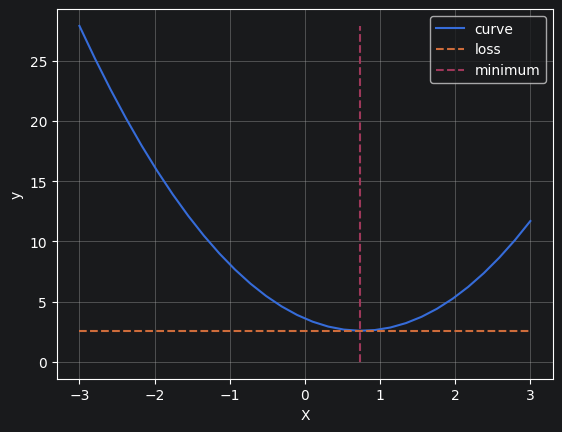

In [5]:
x_plot = np.linspace(-3,3,30)
y_plot = x_plot **2 * a  + b * x_plot + c

plt.plot(x_plot,y_plot,label='curve')


x_best = x.detach().tolist()[0]
loss_min = loss.detach().tolist()[0]
plt.plot([-3,3],[loss_min ,loss_min ],'--',label='loss')

plt.plot([x_best ,x_best],[0 ,y_plot.max() ],'--',label='minimum')
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.grid()

- Experimenta con distintas funciones, con más grado o usa otra funciones en torch (torch.square)

# Dataset y Dataloaders

Dataset son estructuras que permiten cargar datos de manera eficiente y eficaz en un modelo de aprendizaje automático. Son especialmente útiles cuando se trabaja con grandes conjuntos de datos, ya que permiten cargar y procesar los datos de manera incremental, lo que reduce la cantidad de memoria necesaria y mejora el rendimiento del modelo.

En PyTorch, los conjuntos de datos se implementan como clases que heredan de la clase base Dataset. Estas clases deben implementar dos métodos: __len__ y __getitem__. El método __len__ debe devolver el número total de elementos en el conjunto de datos, mientras que el método __getitem__ debe devolver un elemento específico del conjunto de datos dado un índice.



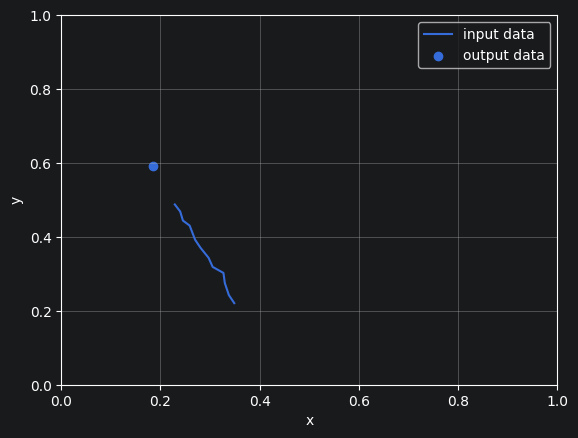

In [6]:
from torch.utils.data import Dataset
class DatasetTracks(Dataset):
    def __init__(self, data, columns_input, columns_output, transform=None):
        self.data = data
        self.columns_input = columns_input
        self.columns_output = columns_output
        self.transform = transform
        self.max_value = data.values.max()
        self.min_value = data.values.min()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, item):
        x = self.data.loc[item,self.columns_input].values
        y = self.data.loc[item,self.columns_output].values
        x = torch.tensor((x -  self.min_value)/( self.max_value - self.min_value))
        y =torch.tensor((y -  self.min_value)/( self.max_value - self.min_value))
        x = x.reshape(-1,len(self.columns_input))
        y = y.reshape(-1,len(self.columns_output))
        return x, y

data = pd.read_csv('../data/data_tarea1.csv')

data_input_names = data.columns[:-2]
data_output_names = data.columns[-2:]
dataset = DatasetTracks(data,columns_input=data_input_names,columns_output=data_output_names
                        )

x_tensor,y_tensor = dataset[4]

fig, ax = plt.subplots()

plt.plot(x_tensor[0,::2],x_tensor[0,1::2], label='input data')
plt.scatter(y_tensor[0,0].tolist(),y_tensor[0,1].tolist(),label='output data')

plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()


## Dataloaders
Los conjuntos de datos se pueden utilizar en combinación con los dataloaders, que son objetos que se encargan de cargar los datos en batches y aplicar transformaciones a los datos antes de ser utilizados por el modelo. Los dataloaders también pueden ser utilizados para realizar el procesamiento de datos en paralelo, lo que mejora el rendimiento del modelo.

En resumen, los conjuntos de datos y los dataloaders son herramientas esenciales para trabajar con grandes conjuntos de datos en PyTorch y mejorar el rendimiento del modelo.

In [7]:
batch_size = 32
lr = 0.01
epochs = 5
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(0)
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size],
                                                   generator=generator)

train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

In [8]:
batch_input,batch_output = next(iter(train_loader))
print(batch_input)
print(batch_output)

tensor([[[0.1253, 0.9564, 0.1362, 0.9319, 0.1580, 0.9101, 0.1717, 0.8747,
          0.1826, 0.8474, 0.2071, 0.8283, 0.2289, 0.7847, 0.2452, 0.7602,
          0.2589, 0.7302, 0.2725, 0.7112, 0.2752, 0.6785, 0.3079, 0.6594]],

        [[0.5831, 0.7275, 0.5804, 0.7248, 0.5695, 0.7166, 0.5559, 0.6975,
          0.5395, 0.6839, 0.5286, 0.6621, 0.5259, 0.6567, 0.4986, 0.6349,
          0.5014, 0.6349, 0.4850, 0.6213, 0.4714, 0.6076, 0.4823, 0.5777]],

        [[0.1553, 0.9837, 0.1826, 0.9728, 0.2044, 0.9646, 0.2343, 0.9482,
          0.2561, 0.9401, 0.2752, 0.9264, 0.2997, 0.9183, 0.3324, 0.9128,
          0.3678, 0.8828, 0.3815, 0.8828, 0.4142, 0.8883, 0.4305, 0.8665]],

        [[0.1308, 0.7493, 0.1471, 0.7466, 0.1526, 0.7711, 0.1635, 0.7793,
          0.1717, 0.7902, 0.1826, 0.7929, 0.1771, 0.8038, 0.1880, 0.8229,
          0.2044, 0.8256, 0.2044, 0.8501, 0.2153, 0.8556, 0.2371, 0.8556]],

        [[0.4550, 0.7575, 0.4741, 0.7657, 0.4796, 0.7711, 0.4850, 0.7793,
          0.4986, 0.7956, 

- Describa que son `batch_input` y `batch_output`.

# Definir una red neuronal
Esto se hace a partir de definir una clase que hereda de nn.Module y que contiene los métodos forward y backward. En el método forward se definen las capas de la red neuronal y en el método backward se definen las operaciones de propagación hacia atrás y ajuste de pesos. Además, se pueden utilizar funciones de activación como ReLU, Sigmoid, Tanh, etc. para mejorar el rendimiento del modelo.

In [9]:

class FeedForwardNet(nn.Module):
    """Basic feedforward network: 2 hidden layers with ReLU activation."""

    def __init__(self, input_features=24, hidden_features=[32,128], output_features=2):
        super().__init__()
        self.layer_1 = nn.Linear(input_features, hidden_features[0])
        self.layer_2 = nn.Linear(hidden_features[0], hidden_features[1])
        self.layer_out = nn.Linear(hidden_features[1], output_features)

    def forward(self, x):
        h = F.relu(self.layer_1(x))
        h = F.relu(self.layer_2(h))
        return self.layer_out(h)



In [10]:
model = FeedForwardNet(input_features=len(data_input_names),
                       hidden_features=[64,128],
                       output_features=len(data_output_names))
print(model.layer_1.weight)
print(model.layer_2.weight)
# print(model.layer_1.weight.size())
# print(model.layer_2.weight.size())

Parameter containing:
tensor([[-0.1529,  0.0342,  0.1729,  ...,  0.1859,  0.1316,  0.0627],
        [ 0.0038, -0.1987, -0.0418,  ...,  0.1767,  0.0330,  0.1810],
        [ 0.1428,  0.1679,  0.0600,  ..., -0.1226,  0.1000, -0.0552],
        ...,
        [-0.1467,  0.0029, -0.1793,  ..., -0.1995,  0.0934, -0.1010],
        [ 0.0360, -0.1621, -0.0964,  ...,  0.1691, -0.0314, -0.1056],
        [ 0.0887,  0.1375,  0.0456,  ...,  0.0735, -0.0496,  0.0452]],
       requires_grad=True)
Parameter containing:
tensor([[-0.0952,  0.0921,  0.0251,  ..., -0.0031, -0.0399,  0.0395],
        [-0.0279, -0.0985, -0.0618,  ..., -0.0849, -0.0841,  0.0297],
        [ 0.1152,  0.0861, -0.0639,  ...,  0.0957,  0.1231,  0.0272],
        ...,
        [ 0.0471, -0.0027,  0.0048,  ..., -0.1250, -0.0641,  0.0872],
        [-0.1098, -0.0789, -0.0768,  ..., -0.0451,  0.0515, -0.0141],
        [-0.0158,  0.0146, -0.0250,  ...,  0.1035,  0.1106, -0.0635]],
       requires_grad=True)


- Que representan estos valores?

# Entrenamiento del modelo
Este es un proceso simple que se basa en dos ciclos for. Uno para las epocas y otro para los batches.

epoch 1/100 - train loss: 0.00138 - val loss: 0.00103
epoch 2/100 - train loss: 0.00135 - val loss: 0.00101
epoch 3/100 - train loss: 0.00131 - val loss: 0.00098
epoch 4/100 - train loss: 0.00128 - val loss: 0.00096
epoch 5/100 - train loss: 0.00124 - val loss: 0.00093
epoch 6/100 - train loss: 0.00121 - val loss: 0.00091
epoch 7/100 - train loss: 0.00118 - val loss: 0.00089
epoch 8/100 - train loss: 0.00115 - val loss: 0.00086
epoch 9/100 - train loss: 0.00112 - val loss: 0.00084
epoch 10/100 - train loss: 0.00109 - val loss: 0.00082
epoch 11/100 - train loss: 0.00106 - val loss: 0.00080
epoch 12/100 - train loss: 0.00103 - val loss: 0.00078
epoch 13/100 - train loss: 0.00101 - val loss: 0.00075
epoch 14/100 - train loss: 0.00098 - val loss: 0.00073
epoch 15/100 - train loss: 0.00095 - val loss: 0.00071
epoch 16/100 - train loss: 0.00093 - val loss: 0.00070
epoch 17/100 - train loss: 0.00090 - val loss: 0.00068
epoch 18/100 - train loss: 0.00088 - val loss: 0.00066
epoch 19/100 - trai

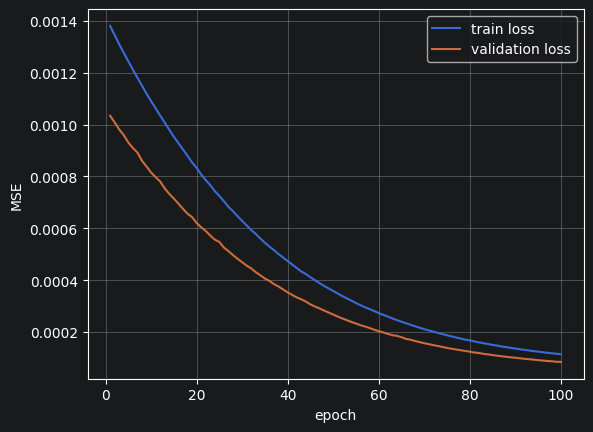

In [69]:

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        # the dataset yields (batch, 1, features), drop the extra axis
        x = x.squeeze(1).float()
        y = y.squeeze(1).float()

        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(x)
    train_loss = running_loss / train_size

    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.squeeze(1).float()
            y = y.squeeze(1).float()
            running_loss += criterion(model(x), y).item() * len(x)
    val_loss = running_loss / val_size

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'epoch {epoch + 1}/{epochs} - train loss: {train_loss:.5f} - val loss: {val_loss:.5f}')

fig, ax = plt.subplots()
plt.plot(range(1, epochs + 1), train_losses, label='train loss')
plt.plot(range(1, epochs + 1), val_losses, label='validation loss')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.grid()
plt.legend()
plt.show()



- Existen tres operaciones importantes en el entrenamiento: la propagación hacia adelante, la propagación hacia atrás y el ajuste de los pesos. Estos en este  codigo esta dados por:
```python
optimizer.zero_grad()
y_pred = model(x) # Propagacion
loss = criterion(y_pred, y)
loss.backward() # Propagacion hacia atras
optimizer.step() # Ajuste de pesos
```

- Grafique algunas predicciones del conjunto de entrenamiento y del conjunto de validacion.

In [81]:
predictions = torch.empty([len(dataset),2])
list(dataset.data.index)[-1]
with torch.no_grad():
    for i in range(len(dataset)):
        sample_x,sample_y=dataset[i]
        sample_x = sample_x.float()
        pred_pos = model(sample_x.float())
        predictions[i] = pred_pos[0]



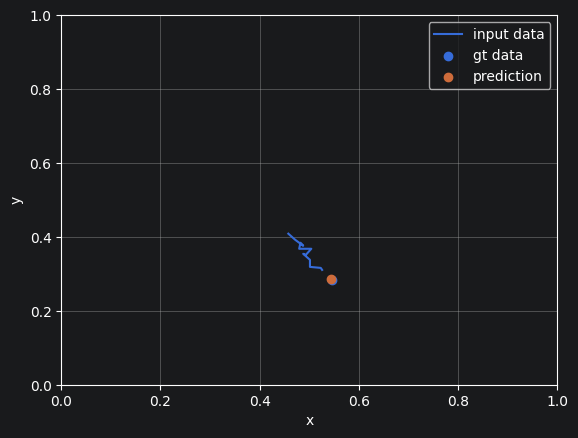

In [82]:
index_target =  9
with torch.no_grad():
    x_tensor,y_tensor = dataset[index_target]

    fig, ax = plt.subplots()

    plt.plot(x_tensor[0,::2],x_tensor[0,1::2], label='input data')
    plt.scatter(y_tensor[0,0].tolist(),y_tensor[0,1].tolist(),label='gt data')
    plt.scatter(predictions[index_target,0].tolist(),predictions[index_target,1].tolist(),label='prediction')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.legend()
    plt.xlim(0,1)
    plt.ylim(0,1)
plt.show()